In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/raw/telco_churn.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100
print("Churn counts:")
print(churn_counts)
print("\nChurn percentage:")
print(churn_percent.round(2))

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


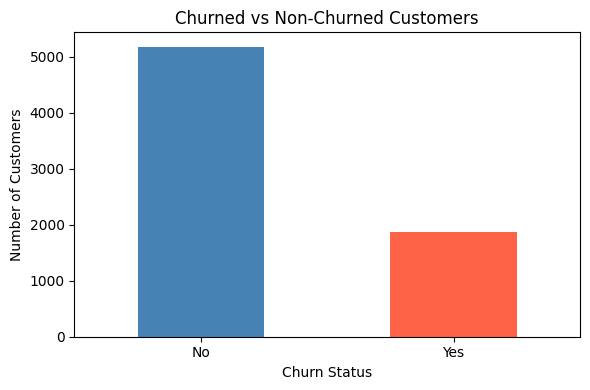

Chart saved to outputs folder


In [6]:
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Churned vs Non-Churned Customers')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/day01_churn_chart.png')
plt.show()
print("Chart saved to outputs folder")

In [7]:
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print("Churn rate by contract type:")
print(churn_by_contract.round(2))

Churn rate by contract type:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


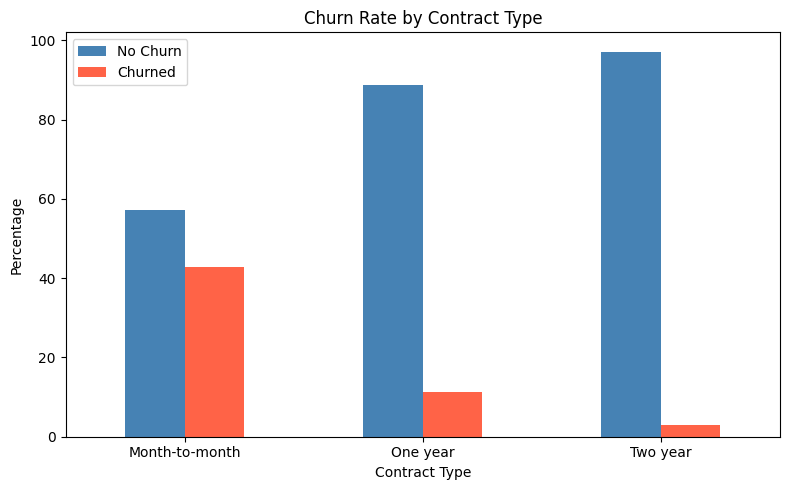

Chart saved


In [8]:
churn_by_contract.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'tomato'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig('../outputs/day01_contract_churn_chart.png')
plt.show()
print("Chart saved")

In [9]:
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print("Average monthly charges:")
print(avg_charges.round(2))

Average monthly charges:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [10]:
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
print("Churn rate by internet service:")
print(internet_churn.round(2))

Churn rate by internet service:
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


In [11]:
senior_churn = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100
print("Churn rate - Senior vs Non-Senior:")
print(senior_churn.round(2))

Churn rate - Senior vs Non-Senior:
Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68


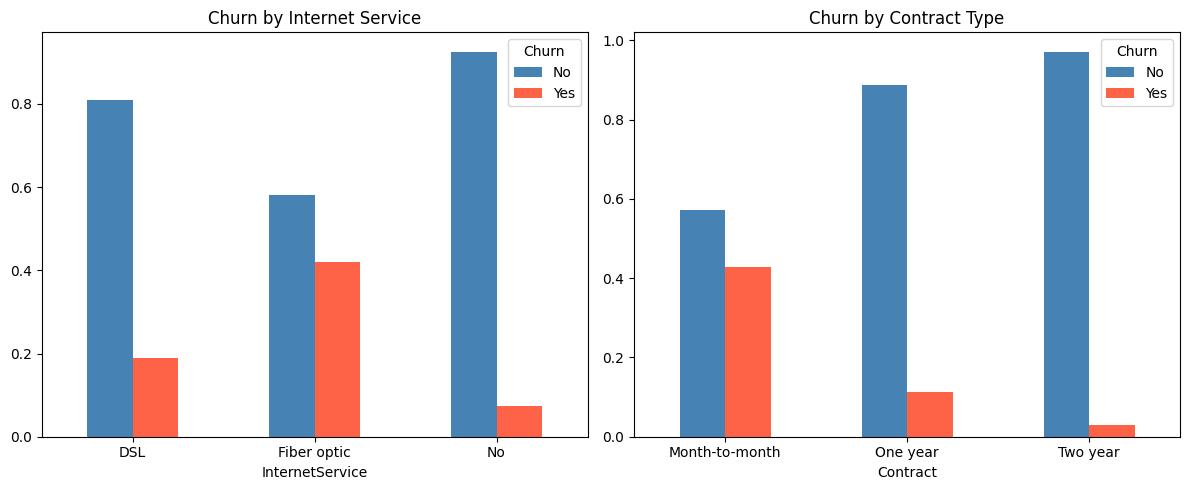

Chart saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('InternetService')['Churn'].value_counts(
    normalize=True).unstack().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'])
axes[0].set_title('Churn by Internet Service')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df.groupby('Contract')['Churn'].value_counts(
    normalize=True).unstack().plot(kind='bar', ax=axes[1],
    color=['steelblue', 'tomato'])
axes[1].set_title('Churn by Contract Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../outputs/day02_churn_analysis.png')
plt.show()
print("Chart saved")